<a href="https://colab.research.google.com/github/Faiva-404/PCVK_Ganjil_2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Faiva Puspa Sahara (06)
> MODUL 5 - Histogram, Histogram Equalization, dan Dithering

C. Sel Identitas (Wajib Menjadi Sel Pertama)

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Faiva Puspa Sahara'
NIM = '244107020036'
N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Faiva Puspa Sahara
NIM : 244107020036 | N = 36
bins   : 8
clip   : 1.5
tile   : 2
L      : 2
WAKTU : 2026-09-29 19:06:48 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 57026f63bb43fcaf




> E-1 Percobaan Histogram



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#import beberapa library

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import glob
import math
import os

Tahap 1

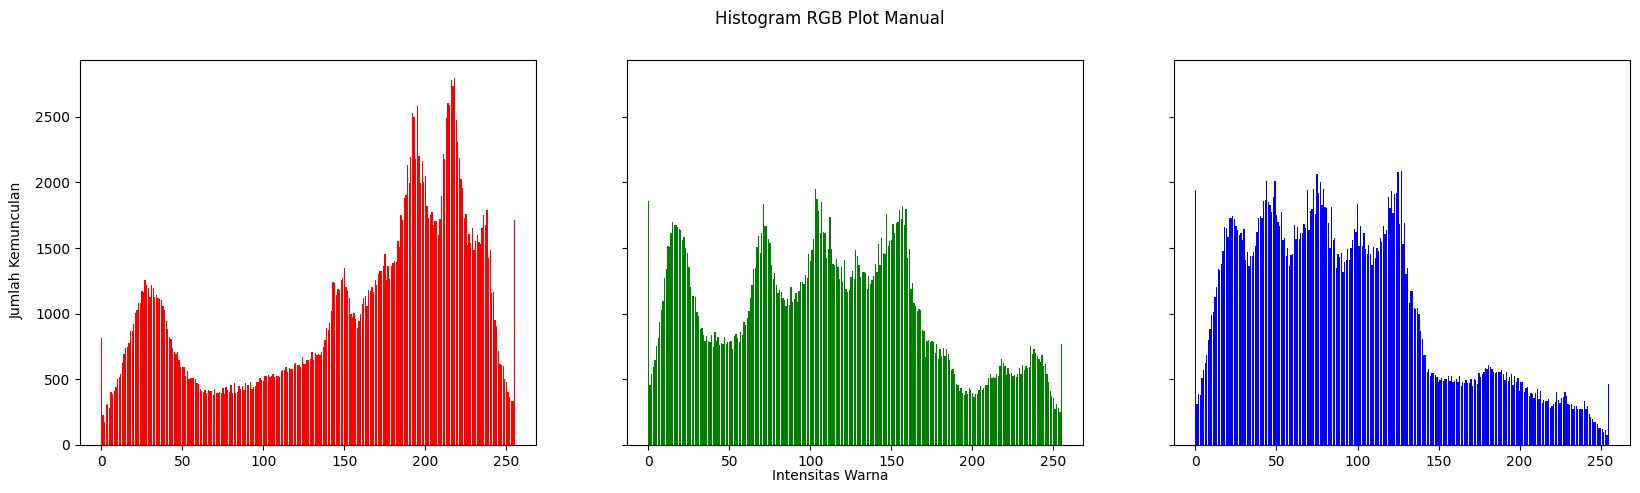

In [ ]:
img = cv.imread('/content/drive/MyDrive/SEMESTER 5/Citra/Lena1.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(height):
  for x in range(width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot Manual')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

Tahap 2

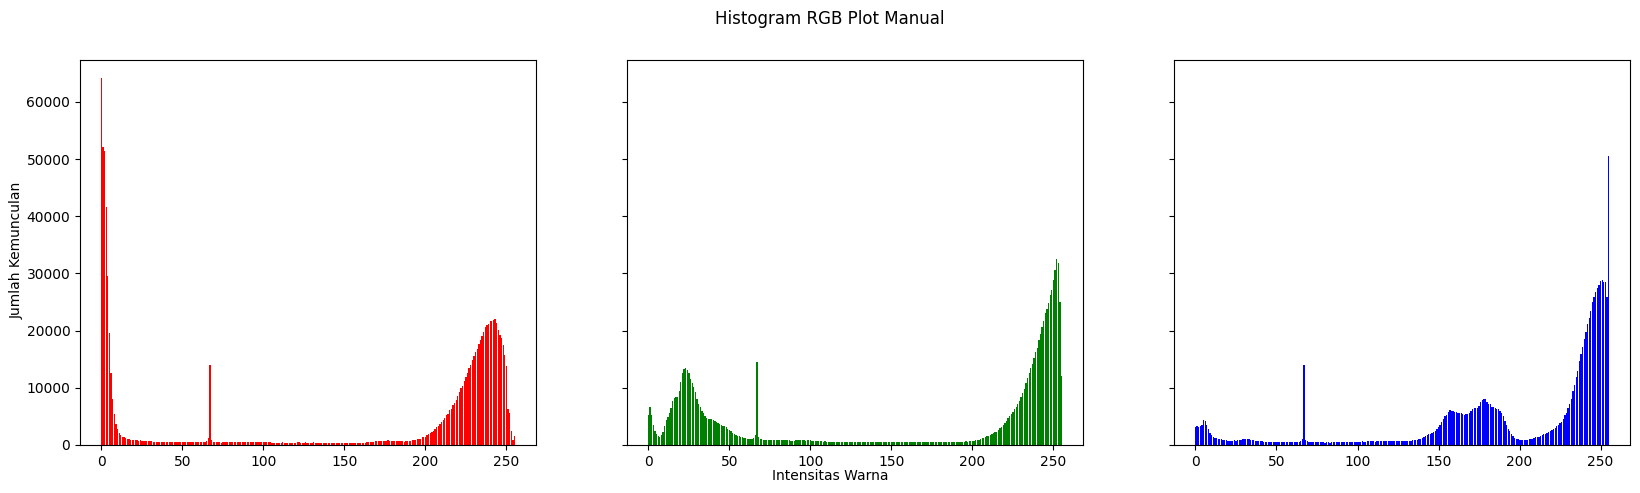

In [ ]:
img = cv.imread('/content/drive/MyDrive/SEMESTER 5/Citra/ktm1b.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(height):
  for x in range(width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot Manual')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()



> Pertanyaan Praktikum E1

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [ ]:
def bandingkan_histogram(path_citra, nim_str):
  gray = cv.imread(path_citra, cv.IMREAD_GRAYSCALE)

  # 1. Manual
  h_manual = np.zeros(256, dtype=np.int64)
  for y in range(gray.shape[0]):
    for x in range(gray.shape[1]):
      h_manual[gray[y, x]] += 1

  # 2. NumPy
  h_numpy, _ = np.histogram(gray.ravel(), bins=256, range=(0, 256))

  # 3. OpenCV
  h_opencv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()

  # Hitung Selisih Maksimum
  diff1 = np.max(np.abs(h_manual - h_numpy))
  diff2 = np.max(np.abs(h_manual - h_opencv))

  print(f'=== Hasil Uji ({os.path.basename(path_citra)}) [{nim_str}] ===')
  print(f'Selisih Maksimum (Manual vs NumPy)  : {diff1}')
  print(f'Selisih Maksimum (Manual vs OpenCV) : {diff2}')
  assert diff1 == 0 and diff2 == 0, 'Histogram tidak identik!'
  print('Pembuktian Berhasil: Selisih NOL.\n')


# Tahap 1: Verifikasi pada lena.jpg
bandingkan_histogram('/content/drive/MyDrive/SEMESTER 5/Citra/Lena1.jpeg', NIM)

# Tahap 2: Penerapan pada KTM1b.jpg
bandingkan_histogram('/content/drive/MyDrive/SEMESTER 5/Citra/ktm1b.jpeg', NIM)

=== Hasil Uji (Lena1.jpeg) [244107020036] ===
Selisih Maksimum (Manual vs NumPy)  : 0
Selisih Maksimum (Manual vs OpenCV) : 0.0
Pembuktian Berhasil: Selisih NOL.

=== Hasil Uji (ktm1b.jpeg) [244107020036] ===
Selisih Maksimum (Manual vs NumPy)  : 0
Selisih Maksimum (Manual vs OpenCV) : 0.0
Pembuktian Berhasil: Selisih NOL.



2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

Analisis Jawaban Pendukung: Citra Paling Gelap (KTM1a.jpg - Ruangan Gelap) memiliki grafik histogram yang menumpuk di sisi kiri (intensitas mendekati 0), sehingga kurva CDF meloncat sangat curam di awal nilai intensitas. Citra Paling Terang (KTM1d.jpg - Luar Ruangan) memiliki distribusi histogram di sisi kanan (intensitas mendekati 255), sehingga kurva CDF tetap landai di awal dan baru melesat naik tajam mendekati nilai intensitas tinggi.

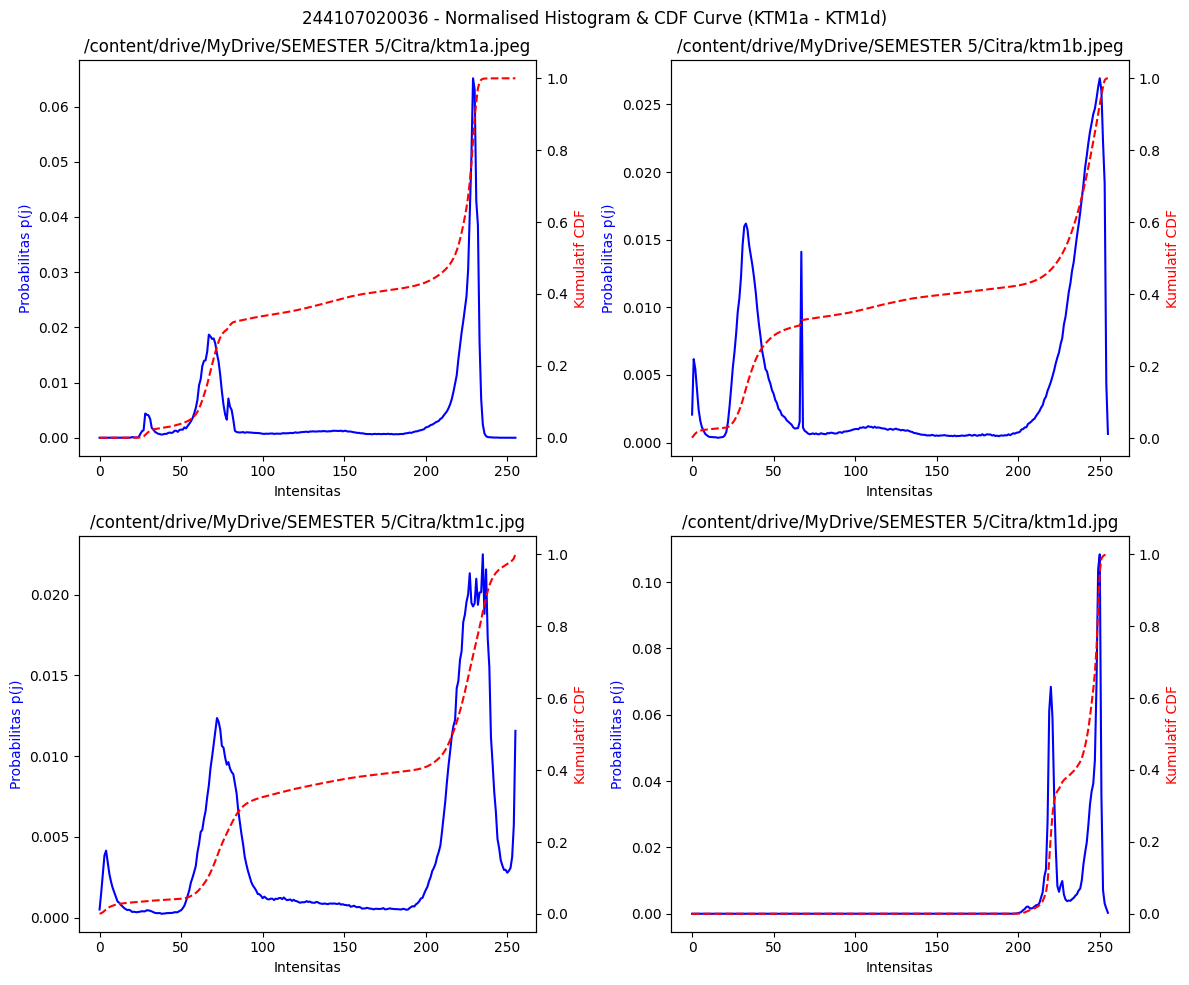

In [ ]:
list_ktm = ['/content/drive/MyDrive/SEMESTER 5/Citra/ktm1a.jpeg',
            '/content/drive/MyDrive/SEMESTER 5/Citra/ktm1b.jpeg',
            '/content/drive/MyDrive/SEMESTER 5/Citra/ktm1c.jpg',
            '/content/drive/MyDrive/SEMESTER 5/Citra/ktm1d.jpg']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'{NIM} - Normalised Histogram & CDF Curve (KTM1a - KTM1d)')

for idx, ktm_file in enumerate(list_ktm):
  ax = axes[idx // 2, idx % 2]
  img = cv.imread(f'{ktm_file}', cv.IMREAD_GRAYSCALE)

  # Calculate Normalized Histogram & CDF
  h = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
  p = h / img.size
  cdf = np.cumsum(p)

  ax.plot(p, color='blue', label='p(j) Normalised')
  ax2 = ax.twinx()
  ax2.plot(cdf, color='red', linestyle='--', label='CDF')

  ax.set_title(f'{ktm_file}')
  ax.set_xlabel('Intensitas')
  ax.set_ylabel('Probabilitas p(j)', color='blue')
  ax2.set_ylabel('Kumulatif CDF', color='red')

plt.tight_layout()
plt.show()

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

Analisis Jawaban Pendukung: Ketika jumlah bin dikurangi (misalnya menjadi 8, 16, atau 32 bin), detail variasi intensitas piksel tingkat halus (fine-grained intensity) hilang karena beberapa rentang nilai intensitas dikelompokkan ke dalam satu batas interval bin.

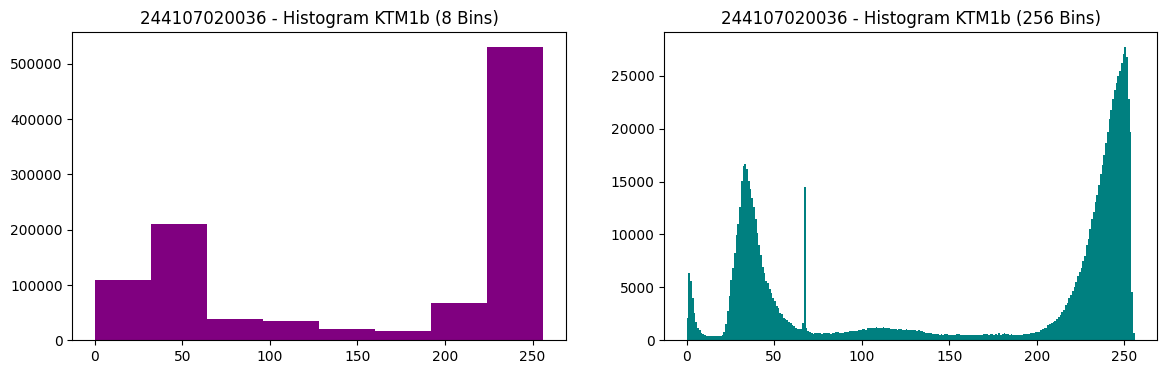

In [ ]:
img_1b = cv.imread('/content/drive/MyDrive/SEMESTER 5/Citra/ktm1b.jpeg', cv.IMREAD_GRAYSCALE)
num_bins = PARAM['bins']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(img_1b.ravel(), bins=num_bins, range=(0, 256), color='purple')
ax1.set_title(f'{NIM} - Histogram KTM1b ({num_bins} Bins)')

ax2.hist(img_1b.ravel(), bins=256, range=(0, 256), color='teal')
ax2.set_title(f'{NIM} - Histogram KTM1b (256 Bins)')

plt.show()



> E-2 PERCOBAAN HISTOGRAM EQUALIZATION



1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses, berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

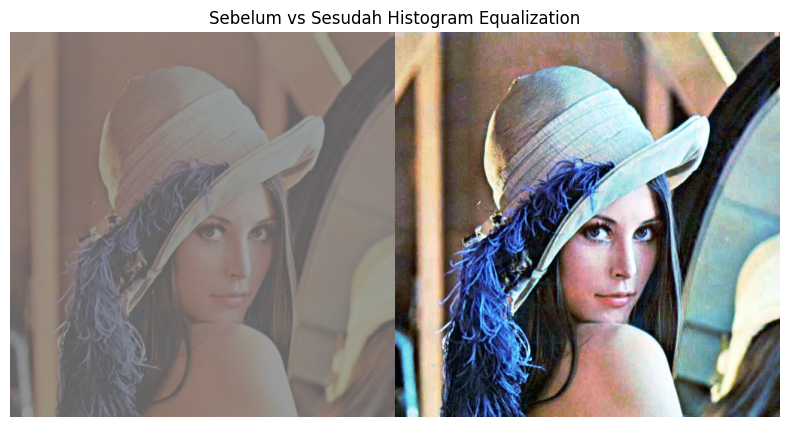

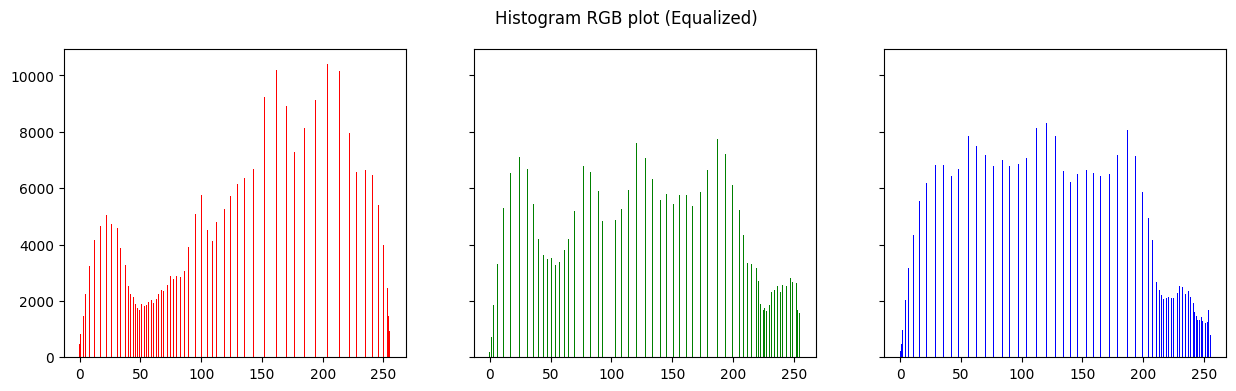

In [ ]:
#Lena

path_lena = '/content/drive/MyDrive/SEMESTER 5/Citra/Lena2.jpeg'

#Baca Citra & Konversi RGB
img_rgb = cv.cvtColor(cv.imread(path_lena), cv.COLOR_BGR2RGB)

#Hitung CDF & Map Warna (Pengganti for loop manual)
img_eq = np.zeros_like(img_rgb)
for i in range(3):
    hist, _ = np.histogram(img_rgb[:, :, i], bins=256, range=(0, 256))
    cdf = hist.cumsum() / img_rgb[:, :, i].size
    img_eq[:, :, i] = np.round(cdf * 255)[img_rgb[:, :, i]]

#Tampilkan Citra Sebelum vs Sesudah
plt.figure(figsize=(10, 5))
plt.imshow(np.hstack((img_rgb, img_eq)))
plt.title(f"Sebelum vs Sesudah Histogram Equalization")
plt.axis('off')
plt.show()

#Tampilkan Histogram RGB Hasil Equalization
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
fig.suptitle(f"Histogram RGB plot (Equalized)")
for i, color in enumerate(['red', 'green', 'blue']):
    hist, _ = np.histogram(img_eq[:, :, i], bins=256, range=(0, 256))
    axs[i].bar(np.arange(256), hist, color=color)
plt.show()

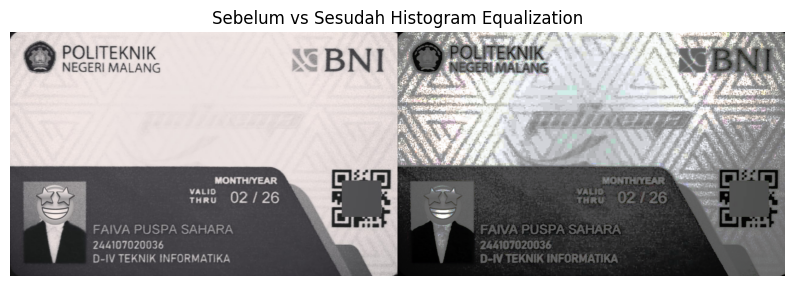

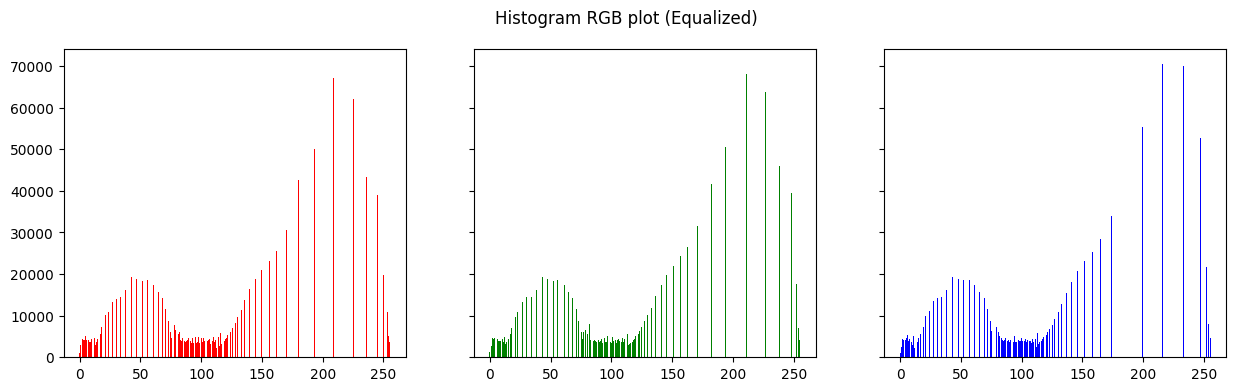

In [ ]:
#KTM

path_ktm1 = '/content/drive/MyDrive/SEMESTER 5/Citra/ktm1a.jpeg'

#Baca Citra & Konversi RGB
img_rgb = cv.cvtColor(cv.imread(path_ktm1), cv.COLOR_BGR2RGB)

#Hitung CDF & Map Warna (Pengganti for loop manual)
img_eq = np.zeros_like(img_rgb)
for i in range(3):
    hist, _ = np.histogram(img_rgb[:, :, i], bins=256, range=(0, 256))
    cdf = hist.cumsum() / img_rgb[:, :, i].size
    img_eq[:, :, i] = np.round(cdf * 255)[img_rgb[:, :, i]]

#Tampilkan Citra Sebelum vs Sesudah
plt.figure(figsize=(10, 5))
plt.imshow(np.hstack((img_rgb, img_eq)))
plt.title(f"Sebelum vs Sesudah Histogram Equalization")
plt.axis('off')
plt.show()

#Tampilkan Histogram RGB Hasil Equalization
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
fig.suptitle(f"Histogram RGB plot (Equalized)")
for i, color in enumerate(['red', 'green', 'blue']):
    hist, _ = np.histogram(img_eq[:, :, i], bins=256, range=(0, 256))
    axs[i].bar(np.arange(256), hist, color=color)
plt.show()

2. buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”

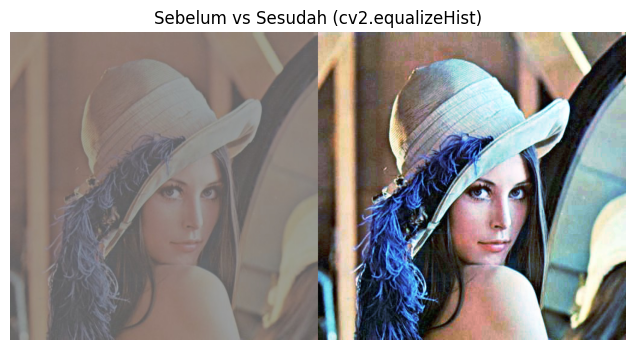

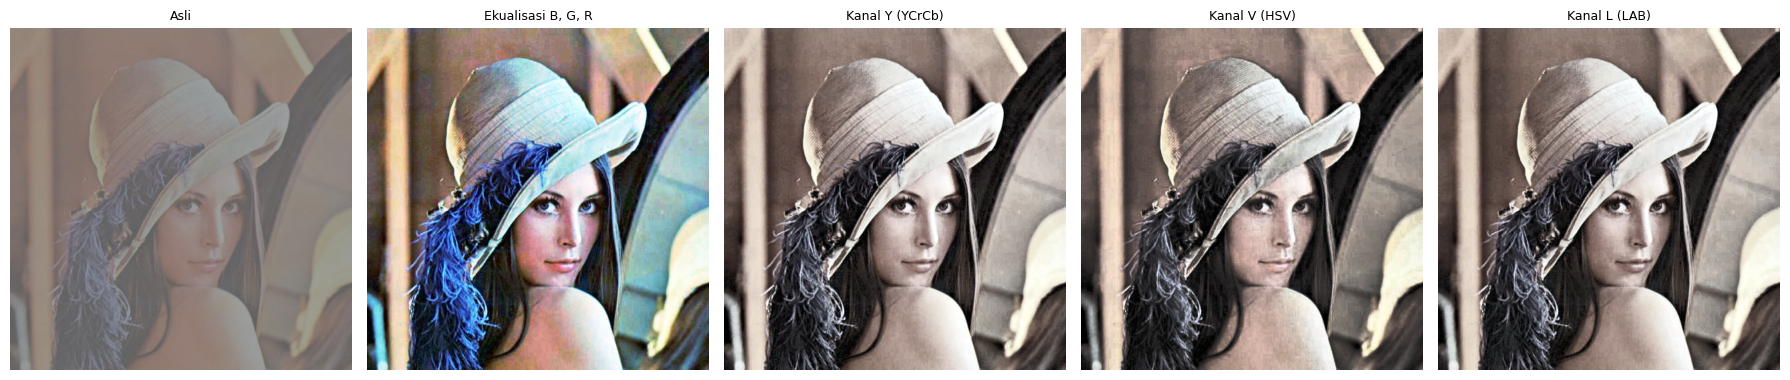

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            126.3
Ekualisasi B, G, R                55.04            130.1
Kanal Y (YCrCb)                    0.12            130.1
Kanal V (HSV)                      3.78            121.7
Kanal L (LAB)                      3.94            125.9
-------------------------------------------------------
CLAHE Kanal L                      3.98            125.5


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

PARAM = {'clip': 2.0, 'tile': 4}  # Parameter CLAHE

# Path citra (Sesuaikan path jika diperlukan)
path_lena = '/content/drive/MyDrive/SEMESTER 5/Citra/Lena2.jpeg'

# Pembacaan Citra Utama
image = cv2.imread(path_lena)
if image is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan di path: {path_lena}")

#2
b, g, r = cv2.split(image)
b_eq = cv2.equalizeHist(b)
g_eq = cv2.equalizeHist(g)
r_eq = cv2.equalizeHist(r)

img_eq_cv2 = cv2.merge([b_eq, g_eq, r_eq])
img_rgb_asli = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_rgb_eq2 = cv2.cvtColor(img_eq_cv2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.imshow(np.hstack((img_rgb_asli, img_rgb_eq2)))
plt.title(f"Sebelum vs Sesudah (cv2.equalizeHist)")
plt.axis('off')
plt.show()

#3
he_rgb = img_eq_cv2
ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)
y, cr, cb = cv2.split(ycrcb)
he_y = cv2.cvtColor(cv2.merge([cv2.equalizeHist(y), cr, cb]), cv2.COLOR_YCrCb2BGR)

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
he_v = cv2.cvtColor(cv2.merge([h, s, cv2.equalizeHist(v)]), cv2.COLOR_HSV2BGR)

lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
l, a, b_lab = cv2.split(lab)
he_l = cv2.cvtColor(cv2.merge([cv2.equalizeHist(l), a, b_lab]), cv2.COLOR_LAB2BGR)

clahe = cv2.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
he_clahe_l = cv2.cvtColor(cv2.merge([clahe.apply(l), a, b_lab]), cv2.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y (YCrCb)', 'Kanal V (HSV)', 'Kanal L (LAB)']
citra_list = [image, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra_list, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv2.cvtColor(c, cv2.COLOR_BGR2RGB))
    plt.title(f"{t}", fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

#Hitung Pergeseran Hue
def geser_hue(asli, hasil):
    h1 = cv2.cvtColor(asli, cv2.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv2.cvtColor(hasil, cv2.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('='*55)
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
print('='*55)
for t, c in zip(judul, citra_list):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(image, c) * 2, cv2.cvtColor(c, cv2.COLOR_BGR2GRAY).mean()))

print('-'*55)
print('%-22s %16.2f %16.1f' % ('CLAHE Kanal L', geser_hue(image, he_clahe_l) * 2, cv2.cvtColor(he_clahe_l, cv2.COLOR_BGR2GRAY).mean()))
print('='*55)



> Pertanyaan Praktikum E-2

1. Ekualisasi global pada citra KTM Anda

a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale.

b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.

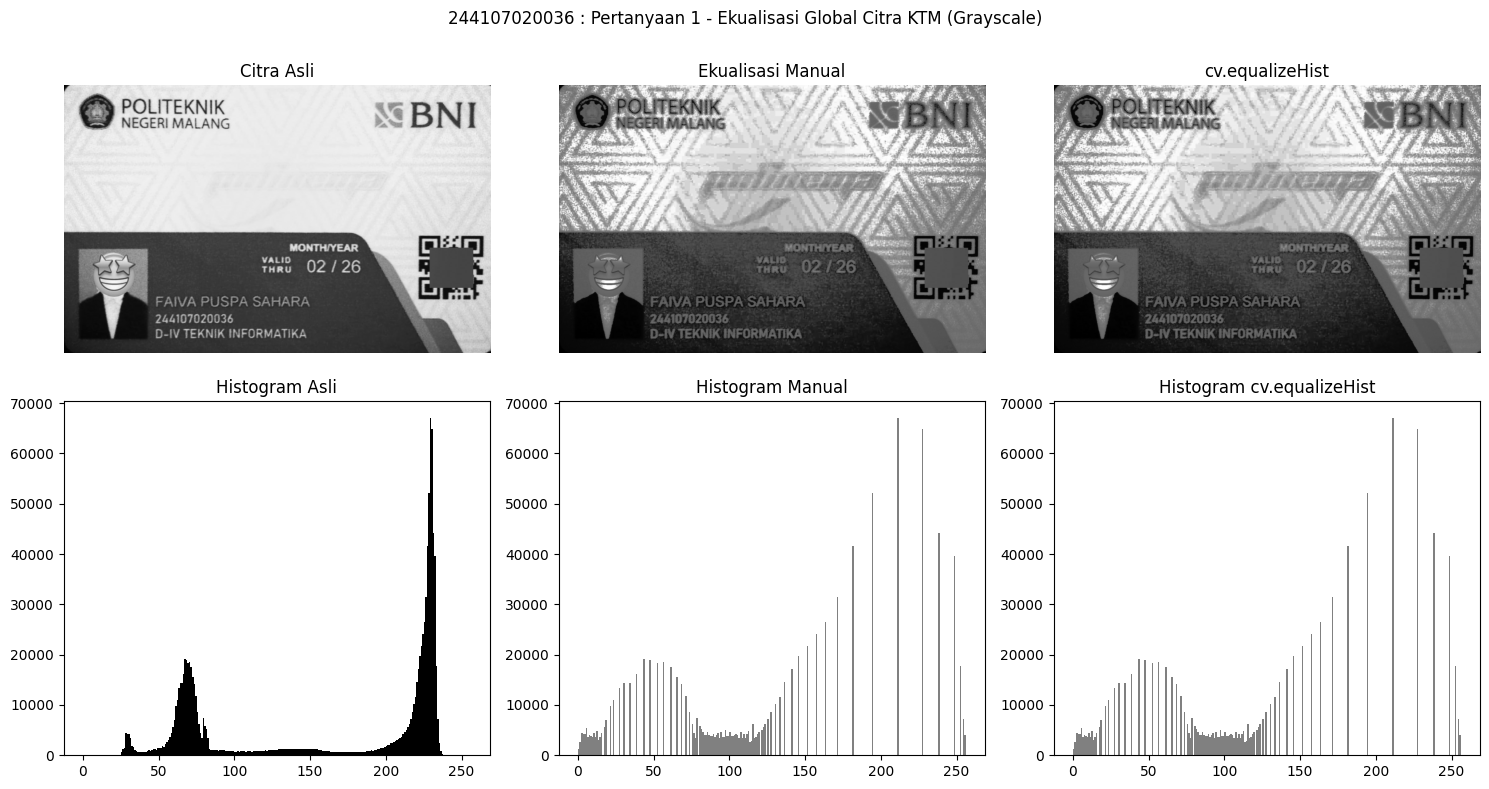

[244107020036] Nilai PSNR antara Citra Asli & Hasil Ekualisasi Global: 14.79 dB


In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread("/content/drive/MyDrive/SEMESTER 5/Citra/ktm1a.jpeg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# a. Ekualisasi Manual
hist_manual, _ = np.histogram(img_gray, bins=256, range=(0, 256))
cdf = hist_manual.cumsum() / img_gray.size
img_eq_manual = np.round(cdf * 255)[img_gray].astype(np.uint8)

# b. Ekualisasi cv.equalizeHist
img_eq_cv2 = cv.equalizeHist(img_gray)

# c. Tampilkan Citra Asli, Hasil Ekualisasi, dan Histogram
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"{NIM} : Pertanyaan 1 - Ekualisasi Global Citra KTM (Grayscale)", fontsize=12)

# Row 1: Citra
axs[0, 0].imshow(img_gray, cmap='gray')
axs[0, 0].set_title('Citra Asli')
axs[0, 0].axis('off')
axs[0, 1].imshow(img_eq_manual, cmap='gray')
axs[0, 1].set_title('Ekualisasi Manual')
axs[0, 1].axis('off')
axs[0, 2].imshow(img_eq_cv2, cmap='gray')
axs[0, 2].set_title('cv.equalizeHist')
axs[0, 2].axis('off')

# Row 2: Histogram
axs[1, 0].hist(img_gray.ravel(), bins=256, range=(0, 256), color='black')
axs[1, 0].set_title('Histogram Asli')
axs[1, 1].hist(img_eq_manual.ravel(), bins=256, range=(0, 256), color='gray')
axs[1, 1].set_title('Histogram Manual')
axs[1, 2].hist(img_eq_cv2.ravel(), bins=256, range=(0, 256), color='gray')
axs[1, 2].set_title('Histogram cv.equalizeHist')
plt.tight_layout()
plt.show()

# d. Perhitungan PSNR
psnr_value = cv.PSNR(img_gray, img_eq_cv2)
print(f"[{NIM}] Nilai PSNR antara Citra Asli & Hasil Ekualisasi Global: {psnr_value:.2f} dB")

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda

a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.

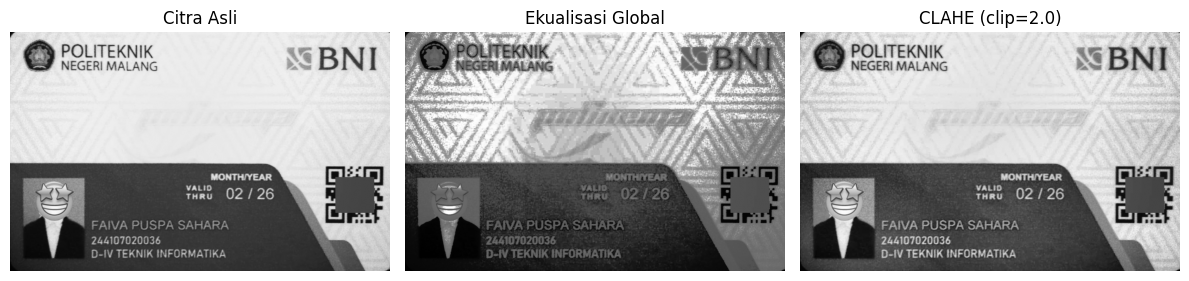

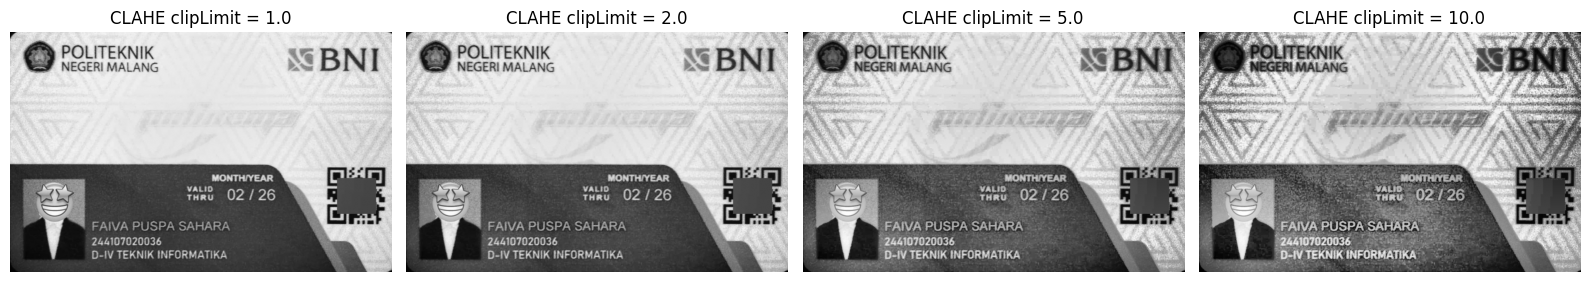

In [ ]:
PARAM = {'clip': 2.0, 'tile': 4}
path_ktm = '/content/drive/MyDrive/SEMESTER 5/Citra/ktm1a.jpeg'

img_gray = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"Gambar gagal dibaca! Periksa kembali path: {path_ktm}")

img_eq = cv.equalizeHist(img_gray)

#a
clahe_base = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
img_clahe_base = clahe_base.apply(img_gray)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title(f"Citra Asli")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_eq, cmap='gray')
plt.title(f"Ekualisasi Global")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_clahe_base, cmap='gray')
plt.title(f"CLAHE (clip={PARAM['clip']})")
plt.axis('off')
plt.tight_layout()
plt.show()

#b
clip_values = [1.0, PARAM['clip'], 5.0, 10.0]
plt.figure(figsize=(16, 4))

for idx, clip in enumerate(clip_values, 1):
    c_obj = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
    res = c_obj.apply(img_gray)

    plt.subplot(1, 4, idx)
    plt.imshow(res, cmap='gray')
    plt.title(f"CLAHE clipLimit = {clip}")
    plt.axis('off')

plt.tight_layout()
plt.show()



> E-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi pada KTM1b.jpg dengan jumlah level PARAM['L'].



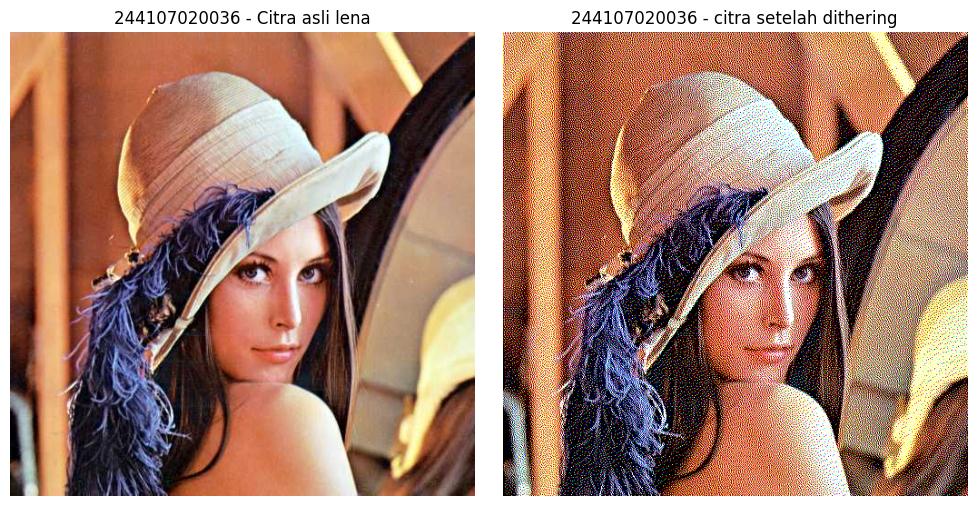

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = '244107020036'
PARAM_L = 2

# 1. DEKLARASI FUNGSI DITHERING (WAJIB ADA DULUAN)
def floyd_steinberg_dither(img, L=2):
    h, w = img.shape[:2]
    img_out = img.astype(np.float32)
    step = 255.0 / (L - 1)

    for y in range(h):
        for x in range(w):
            old_val = img_out[y, x].copy()
            new_val = np.round(old_val / step) * step
            img_out[y, x] = new_val
            err = old_val - new_val

            if x + 1 < w:
                img_out[y, x + 1] += err * 7 / 16
            if y + 1 < h:
                if x - 1 >= 0:
                    img_out[y + 1, x - 1] += err * 3 / 16
                img_out[y + 1, x] += err * 5 / 16
                if x + 1 < w:
                    img_out[y + 1, x + 1] += err * 1 / 16

    return np.clip(img_out, 0, 255).astype(np.uint8)

#PROSES TAHAP 1
path_lena = '/content/drive/MyDrive/SEMESTER 5/Citra/Lena1.jpeg'
img_lena_bgr = cv.imread(path_lena)

if img_lena_bgr is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan di path: {path_lena}")

img_lena_rgb = cv.cvtColor(img_lena_bgr, cv.COLOR_BGR2RGB)

# Jalankan Dithering untuk setiap channel R, G, B
img_dither_lena = np.zeros_like(img_lena_rgb)
for c in range(3):
    img_dither_lena[:, :, c] = floyd_steinberg_dither(img_lena_rgb[:, :, c], L=PARAM_L)

# Tampilkan Hasil
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_lena_rgb)
plt.title(f"{NIM} - Citra asli lena")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_dither_lena)
plt.title(f"{NIM} - citra setelah dithering")
plt.axis('off')

plt.tight_layout()
plt.show()

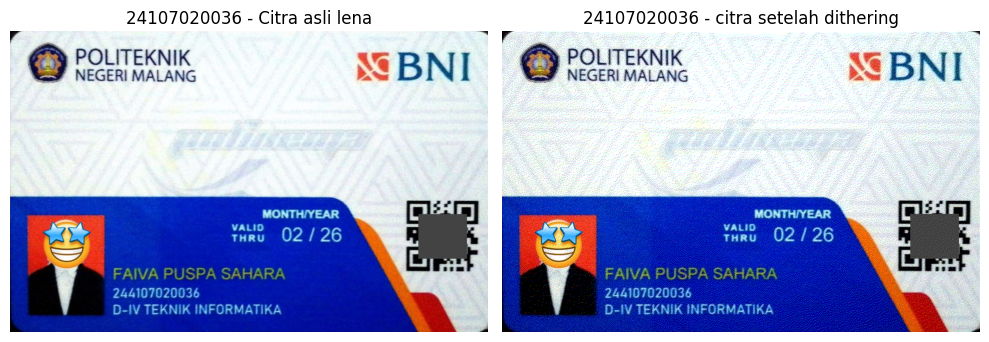

In [ ]:
#PROSES TAHAP 2
path_lena = '/content/drive/MyDrive/SEMESTER 5/Citra/ktm1b.jpeg'
img_lena_bgr = cv.imread(path_lena)

if img_lena_bgr is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan di path: {path_lena}")

img_lena_rgb = cv.cvtColor(img_lena_bgr, cv.COLOR_BGR2RGB)

# Jalankan Dithering untuk setiap channel R, G, B
img_dither_lena = np.zeros_like(img_lena_rgb)
for c in range(3):
    img_dither_lena[:, :, c] = floyd_steinberg_dither(img_lena_rgb[:, :, c], L=PARAM_L)

# Tampilkan Hasil
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_lena_rgb)
plt.title(f"{NIM} - Citra asli lena")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_dither_lena)
plt.title(f"{NIM} - citra setelah dithering")
plt.axis('off')

plt.tight_layout()
plt.show()

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.

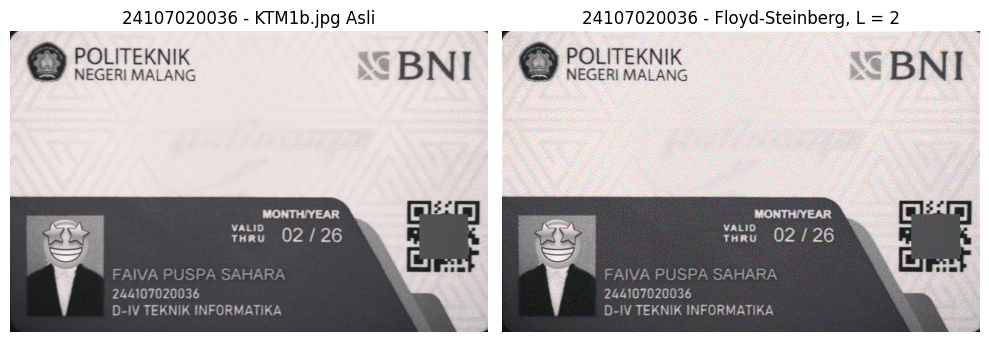

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = '24107020036'
PARAM_L = 2
path_ktm1b = '/content/drive/MyDrive/SEMESTER 5/Citra/ktm1a.jpeg'

img_ktm_bgr = cv.imread(path_ktm1b)

if img_ktm_bgr is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan di path: {path_ktm1b}")

# Konversi dari BGR ke RGB untuk Matplotlib
img_ktm_rgb = cv.cvtColor(img_ktm_bgr, cv.COLOR_BGR2RGB)

img_dither_ktm = np.zeros_like(img_ktm_rgb)
for c in range(3):
    img_dither_ktm[:, :, c] = floyd_steinberg_dither(img_ktm_rgb[:, :, c], L=PARAM_L)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_ktm_rgb)
plt.title(f"{NIM} - KTM1b.jpg Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_dither_ktm)
plt.title(f"{NIM} - Floyd-Steinberg, L = {PARAM_L}")
plt.axis('off')
plt.tight_layout()
plt.show()